# Heterozygosity vs. Missingness Plot

Make sure you have already run:
* `plink --bfile GWA-QC --missing --out GWA-QC`
* `plink --bfile GWA-QC --het --out GWA-QC`

**INPUT:** .imiss + .het files you got by running the above commands <br>
**OUTPUT:** Plot, that helps detect poor-quality or contaminated samples in your genotype data.

In [4]:
# libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# load data

# path to imiss + het files
data_path = "../data/heterozygosityoutliers/"

# due to no autosomal data, the unknown_chip data had to be excluded from this analysis

# List of chip names (prefixes of .imiss/.het files)
chips = ["HTS_iSelect_HD_snpqc", "Illumina_GSAs_snpqc", "OmniExpress_plus_snpqc", "OmniExpress_snpqc"]

# list to hold ind. dataframes
dfs = []

In [6]:
# check het columns for formula
print(het.columns)

Index(['FID', 'IID', 'O(HOM)', 'E(HOM)', 'N(NM)', 'F'], dtype='object')


In [7]:
# merge chips, calculate heterozygosity rate & store in df
for chip in chips:
    # Construct full file paths
    imiss_path = os.path.join(data_path, f"{chip}.imiss")
    het_path = os.path.join(data_path, f"{chip}.het")
    
    # Read the files
    imiss = pd.read_csv(imiss_path, delim_whitespace=True)
    het = pd.read_csv(het_path, delim_whitespace=True)
    
    # Merge by FID and IID
    # inner join: keeps only the rows where both imiss and het have matching values for both FID and IID
    # * If someone has no heterozygosity or missingness estimate, we probably want to exclude them anyway
    # * These are QC plots, and we're mostly interested in individuals with full data
    df = pd.merge(imiss, het, on=["FID", "IID"])
    
    # Calculate heterozygosity rate
    df["HET_RATE"] = (df["N(NM)"] - df["O(HOM)"]) / df["N(NM)"]
    
    # Add chip label
    df["CHIP"] = chip
    
    # Store in list
    dfs.append(df)

# Combine all chips
all_data = pd.concat(dfs, ignore_index=True)

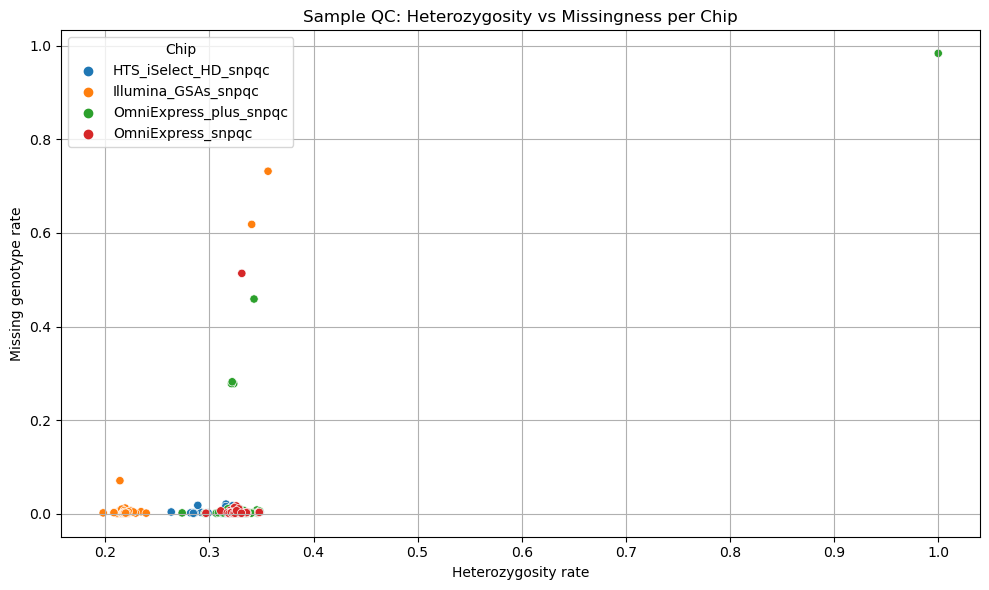

In [8]:
# plot (we love plots)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=all_data, x="HET_RATE", y="F_MISS", hue="CHIP", palette="tab10")
plt.xlabel("Heterozygosity rate")
plt.ylabel("Missing genotype rate")
plt.title("Sample QC: Heterozygosity vs Missingness per Chip")
plt.legend(title="Chip")
plt.grid(True)
plt.tight_layout()
plt.show()

Each point is one sample. We have 802 samples left.
* X-axis: heterozygosity rate
* Y-axis: missing genotype rate
* colors: different genotyping chips

Normal samples should cluster together with **low missing rate** aka y~0. Reasonable heterozygosity lies around ~0.30 ± 0.05. <br>
Outlier samples to check:
* High missingness: points with high y-value
* High heterozygosity: may indicate sample contamination or mix-ups (x > 0.35-0.4) 
* low heterozygosity: could suggest inbreeding or poor genotyping (x < 0.25) -> shit, that's the whole Illumina chip :(
* far from cluster: anything not clustering with the rest of the group

So the points above 0.2 missingness rate are problematic and also the one green point at (1,1), which has 100% missingness and very high heterozygosity.

In [17]:
# check dims of df
all_data.shape

(802, 12)

In [15]:
# check look of df
all_data.head(10)

,FID,IID,MISS_PHENO,N_MISS,N_GENO,F_MISS,O(HOM),E(HOM),N(NM),F,HET_RATE,CHIP
0,10542,10542,Y,409,513445,0.000797,339837,339500.0,499748,0.002235,0.319983,HTS_iSelect_HD_snpqc
1,11076,11076,Y,774,513445,0.001507,339926,339200.0,499393,0.004325,0.319322,HTS_iSelect_HD_snpqc
2,10408,10408,Y,569,513445,0.001108,341060,339400.0,499604,0.010420,0.317339,HTS_iSelect_HD_snpqc
3,10092,10092,Y,1683,513670,0.003276,336203,338700.0,498664,-0.015880,0.325793,HTS_iSelect_HD_snpqc
4,11015,11015,Y,558,513445,0.001087,341569,339400.0,499598,0.013690,0.316312,HTS_iSelect_HD_snpqc
5,11493,11493,Y,899,513445,0.001751,339992,339100.0,499266,0.005308,0.319016,HTS_iSelect_HD_snpqc
6,1378,1378,Y,597,513445,0.001163,340601,339400.0,499566,0.007747,0.318206,HTS_iSelect_HD_snpqc
7,1718,1718,Y,3115,513670,0.006064,340052,337800.0,497258,0.014380,0.316146,HTS_iSelect_HD_snpqc
8,1503,1503,Y,674,513445,0.001313,342640,339300.0,499499,0.020710,0.314033,HTS_iSelect_HD_snpqc
9,1525,1525,Y,1822,513670,0.003547,341061,338600.0,498497,0.015240,0.315821,HTS_iSelect_HD_snpqc


#### Filtering out low quality samples
The code below results in a txt file containing the individuals, which are heterozygosity/missingness outliers. We will use this file with plink to filter out outliers. It is per-chip filtering.

In [31]:
def get_bad_samples(chip, miss_thresh=0.05, sd_thresh=3):
    imiss_path = os.path.join(data_path, f"{chip}.imiss")
    het_path = os.path.join(data_path, f"{chip}.het")
    
    imiss = pd.read_csv(imiss_path, delim_whitespace=True)
    het = pd.read_csv(het_path, delim_whitespace=True)
    
    merged = pd.merge(imiss, het, on=["FID", "IID"])
    
    # missingness filter
    high_miss = merged[merged["F_MISS"] > miss_thresh]
    
    # Heterozygosity filter (F = inbreeding coefficient)
    mean_F = merged["F"].mean() # calc. mean + sd of inbreeding coefficent F
    std_F = merged["F"].std()
    # samples that are too far from average 
    outlier_het = merged[
        (merged["F"] < mean_F - sd_thresh * std_F) |
        (merged["F"] > mean_F + sd_thresh * std_F)
    ]
    
    # Combine and deduplicate
    bad = pd.concat([high_miss, outlier_het]).drop_duplicates(subset=["FID", "IID"])
    return bad[["FID", "IID"]]

In [32]:
for chip in chips:
    bad = get_bad_samples(chip)
    out_path = os.path.join(data_path, f"{chip}.remove")
    bad.to_csv(out_path, sep="\t", index=False, header=False)

In [33]:
for chip in chips:
    bad = get_bad_samples(chip)
    print(f"{chip}: {len(bad)} bad samples")

HTS_iSelect_HD_snpqc: 11 bad samples
Illumina_GSAs_snpqc: 7 bad samples
OmniExpress_plus_snpqc: 8 bad samples
OmniExpress_snpqc: 8 bad samples
